# Train/Validation/Test Rigor + Regression Metrics + Baseline Modeling

<hr>

<center>
<div>
<img src="https://raw.githubusercontent.com/davi-moreira/2026F_predictive_analytics_QM474/main/notebooks/figures/mgmt_474_ai_logo_02-modified.png" width="200"/>
</div>
</center>

# <center><a class="tocSkip"></center>
# <center>QM47400 Predictive Analytics</center>
# <center>Professor: Davi Moreira </center>

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/davi-moreira/2026F_predictive_analytics_QM474/blob/main/notebooks/nb03_regression_metrics_baselines_student.ipynb)

---

## Learning Objectives

By the end of this notebook, you will be able to:

1. Choose regression metrics aligned to business loss (MAE vs RMSE)
2. Establish a baseline model and interpret it correctly
3. Run holdout evaluation without contaminating the test set
4. Use quick diagnostic plots to spot obvious modeling issues
5. Document evaluation decisions (metric, split, baseline, assumptions)

---

> **📋 Participation Reminder:** This notebook contains **2 PAUSE-AND-DO exercises**. You are expected to complete all exercises before submitting your notebook.

---

## 💼 Why This Matters: How Good Is "Good Enough"?

Your preprocessing pipeline at **HomeValue Analytics** is running. The CEO asks: *"So, how much is a house in this neighborhood worth?"* You build your first predictive model — but how do you even know if a prediction is good? If you guess "every house costs USD 207,000" (the average), are you already doing well?

Before celebrating any model, you need a baseline to beat and metrics to measure progress. Otherwise, you might deploy a model that's no better than a spreadsheet average.

> **Today's focus:** Establishing baseline predictions and learning the metrics (MAE, RMSE, R²) that tell us whether our housing price model is actually useful.

---

## 1. Setup

Before HomeValue Analytics can answer the CEO's question — *"How far off are our predictions?"* — we need the standard scientific-Python stack: **pandas** for tabular data, **NumPy** for numerics, **matplotlib/seaborn** for plotting, and several **scikit-learn** modules for splitting, scoring, and modeling. The `DummyRegressor` import may look odd, but it will produce the "guess the average" baseline that every real model must beat.

All random operations use `RANDOM_SEED = 474` so you see identical results. Run the cell below once; the checkmark confirms every library loaded successfully.

In [1]:
# Core imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.precision', 4)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

RANDOM_SEED = 474
np.random.seed(RANDOM_SEED)

print("✓ Setup complete!")

✓ Setup complete!


**Reading the output:**

The single line `Setup complete!` confirms that all imports succeeded and the environment is ready. Behind the scenes, the cell loaded **pandas**, **NumPy**, **matplotlib**, **seaborn**, and five scikit-learn modules: `train_test_split` for partitioning HomeValue's 20,640 census tracts, three metric functions (`mean_absolute_error`, `mean_squared_error`, `r2_score`) for measuring pricing accuracy, `DummyRegressor` for the "predict the average" baseline, `LinearRegression` for the first real model, `Pipeline` and `StandardScaler` for reproducible preprocessing. The global random seed is set to **RANDOM_SEED = 474**, which controls every random operation in this notebook so that your numbers match the solutions exactly.

**Why this matters:** If any import had failed, you would see a `ModuleNotFoundError` here instead of the checkmark. Catching import problems at the top prevents cryptic errors later when you are mid-analysis.

---

## 2. Load Data and Create Splits

HomeValue Analytics has collected **20,640 neighborhood records** from the California Housing dataset, each described by 8 features — `MedInc` (median income), `HouseAge`, `AveRooms`, `AveBedrms`, `Population`, `AveOccup`, `Latitude`, and `Longitude` — with a continuous target: **MedHouseVal** (median house value in units of USD 100,000). Each record is a census **block group** from the 1990 U.S. Census — a small neighborhood of typically 600 to 3,000 residents, which this notebook calls a "tract" for short — and `MedHouseVal` is that neighborhood's recorded median house value in 1990, not the sale price of an individual home. Values above USD 500k are recorded at a ceiling of \~5.0.

We split the data 60/20/20 into train, validation, and test sets using `RANDOM_SEED = 474`. The test set is immediately locked away: all model development proceeds on train + validation only. This mirrors a real deployment scenario where HomeValue's pricing tool will eventually face properties it has never seen.

> 💡 **Gemini Prompt:** "Load the California Housing dataset from scikit-learn as a DataFrame. Separate the target column 'MedHouseVal' from the features. Then split the data into train (60%), validation (20%), and test (20%) sets using train_test_split with random_state=474. Print the sizes of each split."
>
> **After running, verify:**
> - Train set is \~60% of total samples (about 12,384 rows)
> - Validation and test sets are each \~20% (about 4,128 rows)
> - The target variable `y` contains median house values
> - All numerical outputs use standard decimal format — no scientific notation


In [2]:
# Load dataset
california = fetch_california_housing(as_frame=True)
df = california.frame

X = df.drop(columns=['MedHouseVal'])
y = df['MedHouseVal']

# Create splits
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.20, random_state=RANDOM_SEED)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=RANDOM_SEED)

print(f"Train: {len(X_train)} | Validation: {len(X_val)} | Test: {len(X_test)} (LOCKED)")
print(f"\n⚠️ TEST SET IS LOCKED - Do not use until final evaluation!")

Train: 12384 | Validation: 4128 | Test: 4128 (LOCKED)

⚠️ TEST SET IS LOCKED - Do not use until final evaluation!


**Reading the output:**

The split summary shows three partition sizes that sum to **20,640** total census tracts: roughly **12,384 training**, **4,128 validation**, and **4,128 test** records (the exact 60/20/20 ratio). The warning `TEST SET IS LOCKED` is intentional: it reminds HomeValue's data team that those 4,128 tracts must remain untouched until the very last evaluation. Any intermediate peeking at test performance would leak information into model-selection decisions, inflating reported accuracy and undermining the credibility of the pricing tool.

**Key takeaway:** Memorize these counts. When you later compute metrics on the validation set and something looks wrong, come back here to verify you are evaluating on the correct partition — validation (4,128 tracts), not test.

---

## 3. Regression Metrics: MAE, RMSE, R²

HomeValue Analytics needs to report prediction quality in terms the CEO and pricing team understand. Three metrics each tell a different story about the model’s errors. To keep them concrete, the numbers quoted below are the ones this notebook actually produces: the linear regression you will fit in Section 5, scored on the 4,128 validation tracts. Because `MedHouseVal` is measured in units of USD 100,000, a metric value of 0.53 reads as \~USD 53,000.

### Mean Absolute Error (MAE)

MAE answers the question every client asks: *"On average, how far off is the price estimate?"*

$$\text{MAE} = \frac{1}{n} \sum_{i=1}^{n} |y_i - \widehat{y}_i|$$

where $y_i$ is the actual value and $\widehat{y}_i$ is the predicted value for observation $i$.

The linear model's validation MAE of 0.53 means its estimates miss each tract's recorded median house value by \~USD 53,000 on average — same units as `MedHouseVal`, easy to explain in a stakeholder meeting. MAE charges every dollar of error at the same rate: one USD 40k miss contributes exactly as much to the sum of absolute errors as two USD 20k misses.

### Root Mean Squared Error (RMSE)

RMSE answers a different question: *"How large are our misses once the big ones are weighted more heavily?"*

$$\text{RMSE} = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (y_i - \widehat{y}_i)^2}$$

Squaring before averaging makes each miss's contribution grow with its *square*: one USD 40k miss contributes as much to the sum of squared errors as four USD 20k misses ($40^2 = 4 \times 20^2$), and one USD 200k miss as much as a hundred of them. The square root at the end brings the result back to dollars.

**What the validation results mean for HomeValue.** The linear regression you will fit in Section 5 has an MAE of approximately USD 53,000 and an RMSE of approximately USD 72,000. These scores describe errors in predicting each area’s recorded median house value. MAE is the average absolute miss. RMSE summarizes the same errors using squares, so large misses contribute more strongly to its score.

Compared with the mean baseline’s RMSE of approximately USD 116,000, the linear model reduces RMSE by approximately 38%. You therefore have evidence of improvement under a measure that gives large errors extra emphasis. You still need to inspect individual errors before deciding whether performance is adequate for HomeValue’s intended use.

RMSE is always at least as large as MAE for the same observations. Equality occurs when every absolute error has the same size. Their difference reflects variation in error sizes, but neither number identifies which areas have large errors. Section 6 examines those errors directly.

**Choosing between MAE and RMSE.** MAE corresponds to *symmetric absolute loss*: a miss costs in proportion to its size, whether the estimate is too high or too low. RMSE corresponds to *symmetric quadratic loss*: doubling a miss multiplies its contribution by exactly four. Real business costs rarely follow either shape exactly — losing a client can work like a threshold, and over-valuing a property can cost more than under-valuing it — so treat RMSE as a *proxy* for "large misses deserve extra weight," not as a precise model of HomeValue's costs. The choice still matters, because the two metrics can rank models differently: in Section 4 the median baseline beats the mean baseline on validation MAE (0.887 vs. 0.914) but loses on validation RMSE (1.190 vs. 1.160). That pattern is expected, since the median is the constant that minimizes absolute error and the mean the constant that minimizes squared error *on the training data they were computed from* — but on validation data it is an observed result, not a guarantee.

> **A question that often comes up here:** *"Does an RMSE of USD 72,000 mean a new estimate will be within USD 72,000 of the actual value?"* No. RMSE summarizes errors across the validation observations; it does not specify a range for an individual prediction. To describe how often large misses occurred, you can count errors above a stated dollar threshold. A reliable range for a new prediction requires a separate uncertainty assessment.

### R² (Coefficient of Determination)

R² tells the board what fraction of the variability in the evaluated outcomes the model accounts for:

$$R^2 = 1 - \frac{SS_{\text{res}}}{SS_{\text{tot}}} = 1 - \frac{\sum_{i=1}^{n}(y_i - \widehat{y}_i)^2}{\sum_{i=1}^{n}(y_i - \bar{y})^2}$$

where $SS_{\text{res}}$ is the sum of squared residuals (model errors), $SS_{\text{tot}}$ is the total sum of squares, and $\bar{y}$ is the mean of the outcomes *being evaluated* — so on the validation set, R² compares the model with predicting the validation mean for every tract.

- **R² = 1.0**: Perfect predictions — never happens in practice
- **R² = 0.0**: No better than predicting the mean of the evaluated outcomes
- **R² < 0**: *Worse* than predicting that mean — possible on validation data, even for a constant baseline that predicts the *training* mean or median

The linear model's validation R² is 0.617: its squared error is \~61.7% lower than predicting the validation mean for every tract. The remaining \~38% of the variation is *unexplained by this model* — some of it better features and more flexible models may capture in later notebooks, and some may not be predictable from these features at all.

> **Which metric should HomeValue report?** Declare one **primary metric** before comparing models — the one whose loss best matches the intended use (MAE if the cost of a miss grows roughly in proportion to its size, RMSE if large misses deserve extra weight) — and use it to pick the winner. Then report the same supporting scores (the other error metric and R²) for every model in every table, so no audience ever sees a metric chosen after the results came in.

> 💡 **Gemini Prompt:** "Write a Python function called `evaluate_regression` that takes `y_true`, `y_pred`, and an optional `name` parameter. It should compute MAE (mean absolute error), RMSE (root mean squared error), and R-squared. Return the results as a dictionary with keys 'Model', 'MAE', 'RMSE', and 'R²'."
>
> **After running, verify:**
> - Function returns a dictionary with exactly 4 keys: 'Model', 'MAE', 'RMSE', 'R²'
> - RMSE is computed as the square root of mean_squared_error (not MSE itself)
> - Function uses scikit-learn's `mean_absolute_error`, `mean_squared_error`, and `r2_score`
> - All numerical outputs use standard decimal format — no scientific notation


In [3]:
def evaluate_regression(y_true, y_pred, name="Model"):
    """
    Compute standard regression metrics.
    
    Parameters:
    -----------
    y_true : array-like
        True target values
    y_pred : array-like
        Predicted values
    name : str
        Name for reporting
    
    Returns:
    --------
    dict : Dictionary of metrics
    """
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    
    metrics = {
        'Model': name,
        'MAE': mae,
        'RMSE': rmse,
        'R²': r2
    }
    
    return metrics

print("✓ Evaluation function created")

✓ Evaluation function created


**Reading the output:**

The message `Evaluation function created` tells you the helper `evaluate_regression()` is now available in memory, ready to score any model HomeValue builds. The function accepts true values, predicted values, and a label, then returns a dictionary with three metrics: **MAE** (average dollar error), **RMSE** (penalizing large misses), and **R²** (variance explained). No predictions have been made yet; the function simply waits for inputs.

**Why this matters:** Centralizing metric computation in one function prevents copy-paste errors. Every model in this notebook — from the "guess the mean" baseline to the first linear regression — will be scored through the same function, guaranteeing consistent, apples-to-apples comparisons for HomeValue's pricing-accuracy reports.

---

## 4. Baseline Models

### 4.1 Why Baselines Matter

Before HomeValue invests in sophisticated algorithms, the CEO needs to know: *"How well does a no-skill prediction perform?"* The simplest strategy is to predict the training-set average price for every property — roughly USD 207,000 for every census tract, regardless of income, location, or size. If a regression model cannot beat this naive guess, the entire investment in data collection and feature engineering has added no value.

We build two baselines:

- **Mean baseline**: Predicts the training-set mean for all samples:

$$\widehat{y}_i = \bar{y}_{\text{train}} = \frac{1}{n_{\text{train}}} \sum_{j=1}^{n_{\text{train}}} y_j$$

- **Median baseline**: Predicts the training-set median instead (more robust to outliers like the USD 500k-capped tracts):

$$\widehat{y}_i = \text{median}(y_{\text{train}})$$

Both strategies ignore all features entirely — they produce the same prediction regardless of income, location, or house size. These establish the performance floor. Every model HomeValue builds from here on must clear this bar.

> **Note:** On the training set, the mean baseline yields R² = 0.0 exactly, since it predicts the training mean and R² measures improvement over predicting the mean of the outcomes being evaluated. On the validation set, R² compares against the *validation* mean, so the training-mean baseline lands just below zero (about −0.000006) and the median baseline lower still (about −0.05). A clearly positive validation R² from a real model is evidence that it learned something useful from the features.

> 💡 **Gemini Prompt:** "Create two baseline models using scikit-learn's `DummyRegressor`: one with strategy='mean' and one with strategy='median'. Fit each on the training data, then generate predictions for both the training and validation sets."
>
> **After running, verify:**
> - Both `DummyRegressor` models are fitted on `X_train` and `y_train`
> - Predictions are generated for both train and validation sets (4 prediction arrays total)
> - Mean baseline predictions should all be the same value (the training set mean)
> - All numerical outputs use standard decimal format — no scientific notation


In [4]:
# Mean baseline
baseline_mean = DummyRegressor(strategy='mean')
baseline_mean.fit(X_train, y_train)
y_pred_mean_train = baseline_mean.predict(X_train)
y_pred_mean_val = baseline_mean.predict(X_val)

# Median baseline
baseline_median = DummyRegressor(strategy='median')
baseline_median.fit(X_train, y_train)
y_pred_median_train = baseline_median.predict(X_train)
y_pred_median_val = baseline_median.predict(X_val)

print("✓ Baseline models fitted")

✓ Baseline models fitted


**Reading the output:**

The message `Baseline models fitted` confirms that two `DummyRegressor` objects are now trained: one predicting the training-set mean of `MedHouseVal` (\~USD 207k) for every tract, and one predicting the median. Despite sounding trivial, fitting a dummy regressor is necessary so scikit-learn stores the learned constant and can later call `.predict()` consistently. These baselines represent the absolute floor of performance — the price a client would get if HomeValue simply said "every house costs USD 207,000."

**Key takeaway:** Baselines require almost no computation, yet they give HomeValue the single most important reference number: the error to beat. Always establish a baseline before building complex models — it takes 10 seconds and saves you from celebrating a model that adds no value.

---

## 📝 PAUSE-AND-DO Exercise 1 (5 minutes)

**Task:** Write `evaluate_regression(y_true, y_pred)` returning MAE/RMSE/R².

The function is already implemented above. Now:
1. Use it to evaluate both baselines on train and validation sets
2. Create a comparison table
3. Interpret the results

---

> 💡 **Gemini Prompt:** "Evaluate both baseline models (mean and median) on training and validation sets using the `evaluate_regression` function. Collect results into a list, convert to a DataFrame, and print a comparison table. Also print the MAE interpretation in dollar terms (values are in USD 100,000s). Then create a bar plot comparing MAE, RMSE, and R² across the baseline models (validation set only), using a grouped bar chart with one group per metric."
>
> **After running, verify:**
> - Results DataFrame has 4 rows: Mean Baseline (Train), Mean Baseline (Val), Median Baseline (Train), Median Baseline (Val)
> - R² is 0.0 (or near 0) for the mean baseline on training data
> - MAE values are displayed and interpreted in context (multiply by USD 100,000)
> - Bar plot clearly shows metric values for each baseline model on the validation set
> - All numerical outputs use standard decimal format — no scientific notation


In [5]:
# YOUR SOLUTION CODE HERE
# Hint: Use the Gemini prompt above for step-by-step guidance


## 5. Simple Linear Model

The baselines told HomeValue what "doing nothing smart" looks like: \~USD 91,000 average error on every price estimate. Now we test whether even the simplest machine-learning model — ordinary linear regression — can beat that guess-the-mean strategy by learning relationships between features like `MedInc`, `Latitude`, and `AveRooms` and the target `MedHouseVal`.

We wrap a `StandardScaler` and `LinearRegression` inside a scikit-learn `Pipeline` so that scaling and fitting happen in a single reproducible step. If this model cannot improve over the USD 91k baseline, something fundamental is wrong with the features or the data — and HomeValue should investigate before investing in more complex algorithms.

> 💡 **Gemini Prompt:** "Create a scikit-learn Pipeline that first applies `StandardScaler` and then fits a `LinearRegression` model. Fit it on the training data and generate predictions for both training and validation sets."
>
> **After running, verify:**
> - Pipeline has two steps: 'scaler' (StandardScaler) and 'regressor' (LinearRegression)
> - Pipeline is fitted on `X_train` and `y_train` only
> - Predictions are generated for both train and validation sets
> - All numerical outputs use standard decimal format — no scientific notation


In [7]:
# Create pipeline with scaling + linear regression
linear_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', LinearRegression())
])

# Fit on training data
linear_pipeline.fit(X_train, y_train)

# Predict
y_pred_linear_train = linear_pipeline.predict(X_train)
y_pred_linear_val = linear_pipeline.predict(X_val)

print("✓ Linear model fitted")

✓ Linear model fitted


**Reading the output:**

The confirmation `Linear model fitted` means the Pipeline has estimated a coefficient for each of HomeValue's 8 housing features — `MedInc`, `HouseAge`, `AveRooms`, `AveBedrms`, `Population`, `AveOccup`, `Latitude`, and `Longitude` — after first standardizing them to a common scale. Without scaling, `Latitude` (values \~34–42) and `MedInc` (values \~0–15) would have incomparable coefficient magnitudes, making it impossible to tell which feature drives HomeValue's price estimates.

No metrics are printed yet; the next step will reveal whether this first real model beats the \~USD 91,000-error baseline. If it does, HomeValue has evidence that its 8 features carry genuine predictive signal — and that the data-collection investment was worthwhile. If it doesn't, something is fundamentally wrong with either the data or the model.

**Key takeaway:** The `Pipeline` ensures scaling and fitting happen as one atomic operation, preventing *fit-transform leakage*. For HomeValue, this means reported accuracy improvements are trustworthy, not artifacts of a pipeline mistake.

---

## 📝 PAUSE-AND-DO Exercise 2 (5 minutes)

**Task:** Compare baseline vs linear regression and interpret the delta.

---

> 💡 **Gemini Prompt:** "Evaluate the linear regression model on train and validation sets using `evaluate_regression`, append to the existing results list, and create a full comparison DataFrame. Calculate the percentage improvement in validation MAE of linear regression over the mean baseline and over the median baseline, and label each result with the baseline it compares against. Then create a bar plot comparing MAE, RMSE, and R² across all models (validation set only), using a grouped bar chart with one group per metric."
>
> **After running, verify:**
> - Full results DataFrame has 6 rows (4 baseline + 2 linear regression)
> - Linear regression R² on validation is substantially above 0 (model learns patterns)
> - Each improvement percentage is computed as `(baseline_MAE - linear_MAE) / baseline_MAE * 100` and is labeled with its baseline (mean or median)
> - Bar plot clearly shows metric values for all models on the validation set
> - All numerical outputs use standard decimal format — no scientific notation


In [8]:
# YOUR SOLUTION CODE HERE
# Hint: Use the Gemini prompt above for step-by-step guidance


### YOUR INTERPRETATION HERE:

**Observation 1: Performance**  
[How much better is linear vs baseline?]

**Observation 2: Overfitting Check**  
[Compare train vs validation scores - is there overfitting?]

**Observation 3: Business Context**  
[What does this MAE mean in practical terms?]

---

## 6. Residual Analysis

A residual is the gap between what HomeValue predicted and the recorded median house value: **Residual = Actual − Predicted**. Plotting residuals reveals *patterns* in the model's mistakes that a single MAE number hides.

Good residuals should:
- Be centered around zero (no systematic over- or under-prediction)
- Show no patterns (random scatter, not curves or clusters)
- Have roughly constant variance (the model is equally reliable for USD 100k and USD 400k tracts)

If the scatter fans out for expensive properties, HomeValue's pricing tool is less trustworthy in exactly the segment where errors cost the most.

> 💡 **Gemini Prompt:** "Calculate residuals (actual minus predicted) for the linear regression model on both training and validation sets. Create a 2x2 subplot figure: top row shows residuals vs predicted values (scatter with y=0 reference line) for train and validation; bottom row shows residual histograms for train and validation. Print residual mean and standard deviation."
>
> **After running, verify:**
> - Residuals are computed as `y_true - y_pred` (not the reverse)
> - All four subplots display correctly: two scatter plots (top) and two histograms (bottom)
> - Residual means are very close to zero (especially for the training set)
> - All numerical outputs use standard decimal format — no scientific notation


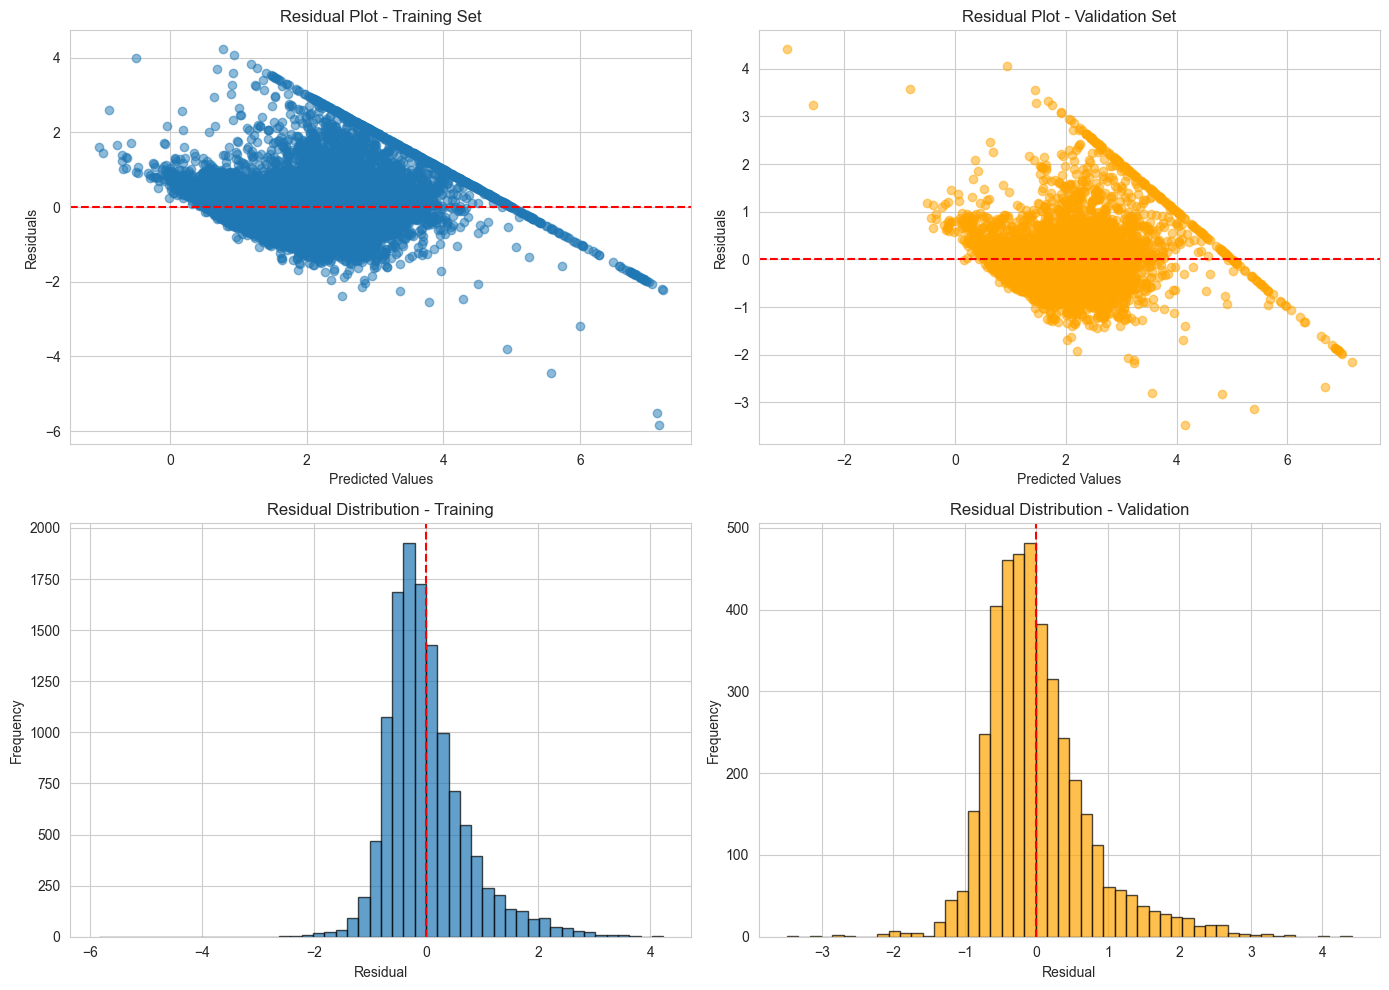

=== RESIDUAL STATISTICS ===
Training residuals: mean=-0.000000, std=0.7239
Validation residuals: mean=0.005840, std=0.7182

=== LARGE MISSES (VALIDATION) ===
Median absolute error: 0.4075
Largest 10% of absolute errors (413 tracts): 31.7% of total absolute error, 59.7% of total squared error
Negative predictions: 24
Worst miss: actual=1.375, predicted=-3.035, AveOccup=1243


In [10]:
# Calculate residuals
residuals_train = y_train - y_pred_linear_train
residuals_val = y_val - y_pred_linear_val

# Create residual plots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Residuals vs Predicted (Train)
axes[0, 0].scatter(y_pred_linear_train, residuals_train, alpha=0.5)
axes[0, 0].axhline(y=0, color='r', linestyle='--')
axes[0, 0].set_xlabel('Predicted Values')
axes[0, 0].set_ylabel('Residuals')
axes[0, 0].set_title('Residual Plot - Training Set')

# Plot 2: Residuals vs Predicted (Validation)
axes[0, 1].scatter(y_pred_linear_val, residuals_val, alpha=0.5, color='orange')
axes[0, 1].axhline(y=0, color='r', linestyle='--')
axes[0, 1].set_xlabel('Predicted Values')
axes[0, 1].set_ylabel('Residuals')
axes[0, 1].set_title('Residual Plot - Validation Set')

# Plot 3: Distribution of Residuals (Train)
axes[1, 0].hist(residuals_train, bins=50, alpha=0.7, edgecolor='black')
axes[1, 0].axvline(x=0, color='r', linestyle='--')
axes[1, 0].set_xlabel('Residual')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Residual Distribution - Training')

# Plot 4: Distribution of Residuals (Validation)
axes[1, 1].hist(residuals_val, bins=50, alpha=0.7, color='orange', edgecolor='black')
axes[1, 1].axvline(x=0, color='r', linestyle='--')
axes[1, 1].set_xlabel('Residual')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Residual Distribution - Validation')

plt.tight_layout()
plt.show()

print("=== RESIDUAL STATISTICS ===")
print(f"Training residuals: mean={residuals_train.mean():.6f}, std={residuals_train.std():.4f}")
print(f"Validation residuals: mean={residuals_val.mean():.6f}, std={residuals_val.std():.4f}")

# Where the large validation misses are
abs_err_val = residuals_val.abs()
n_top = int(np.ceil(0.10 * len(abs_err_val)))
largest = abs_err_val.sort_values(ascending=False).head(n_top)
print("\n=== LARGE MISSES (VALIDATION) ===")
print(f"Median absolute error: {abs_err_val.median():.4f}")
print(f"Largest 10% of absolute errors ({n_top} tracts): "
      f"{largest.sum() / abs_err_val.sum():.1%} of total absolute error, "
      f"{(largest ** 2).sum() / (residuals_val ** 2).sum():.1%} of total squared error")
print(f"Negative predictions: {(y_pred_linear_val < 0).sum()}")
worst = abs_err_val.values.argmax()
print(f"Worst miss: actual={y_val.iloc[worst]:.3f}, predicted={y_pred_linear_val[worst]:.3f}, "
      f"AveOccup={X_val['AveOccup'].iloc[worst]:.0f}")

**Reading the output:**

The 2x2 grid shows four panels. **Top row**: residuals (actual minus predicted `MedHouseVal`) plotted against predicted values for train (left) and validation (right). Ideally you want a formless cloud centered on the red zero-line; any visible pattern (funnel, curve, clustering) signals a problem the model is missing. **Bottom row**: histograms of residuals for train and validation. Read them for four features rather than for a perfect bell shape: the **center** (is the bulk of the errors near zero?), the **spread** (how wide is a typical miss?), the **asymmetry** (does one tail stretch further? A long right tail means tracts the model under-prices by a lot), and **unusual observations** (isolated bars far from the rest).

The printed statistics put numbers on those features. The mean residual is near zero (exactly zero on the training set, by construction for least squares with an intercept), and the standard deviation (\~0.72) matches the RMSE from Section 5 almost exactly, because the errors average out to about zero. The validation **median absolute error** is \~0.41, or \~USD 41,000: half of the tracts are missed by less than that, below the \~USD 53,000 MAE, because a minority of large misses pulls the average up. That minority is concentrated: the largest 10% of absolute errors (413 tracts) make up \~32% of the total absolute error but \~60% of the total squared error — which is exactly why large misses move RMSE much more than MAE.

The extreme cases deserve a look of their own. The model produces **24 negative price predictions** on the validation set, and the single worst miss (\~USD 441,000) is not a luxury tract: it is a tract with a recorded median value of \~USD 137,500 that the model predicts at about **−USD 303,000**, alongside an extreme `AveOccup` of \~1,243 people per household. A linear model has no floor, so one unusual feature value can push its prediction far outside any plausible price. That calls for checking the feature's plausibility and the model's behavior — not for deleting the record automatically.

**Key takeaway:** If you see a clear funnel shape (variance increasing with predicted value), the model exhibits *heteroskedasticity*: errors grow for the neighborhoods the model prices highest. This is common in housing data and flags a business risk — one overall RMSE understates how uncertain HomeValue's estimates are for that segment, so any reliability statement for expensive neighborhoods needs its own assessment rather than the overall figure.

---

## 7. Predicted vs Actual Plot

A predicted-vs-actual scatter plot is the most intuitive diagnostic HomeValue can show to a non-technical stakeholder. Every point represents one census tract; the x-axis is the true `MedHouseVal` and the y-axis is the model's prediction.

Perfect predictions fall exactly on the red 45-degree diagonal. Systematic deviations from the line reveal regions where HomeValue's model consistently over- or under-predicts. Watch the right edge too: because the dataset records every median value above USD 500k at a ceiling of \~5.0, those tracts form a **vertical** column of points that share one actual value while their predictions spread up and down. We plot train and validation side by side to check whether the model generalizes.

> 💡 **Gemini Prompt:** "Create a side-by-side predicted vs actual scatter plot for the linear regression model. Plot training set on the left and validation set on the right. Add a red dashed 45-degree reference line (perfect predictions) on each subplot."
>
> **After running, verify:**
> - The 45-degree reference line goes from min to max of actual values
> - Points clustered near the red line indicate good predictions
> - Training and validation plots show similar scatter patterns (no severe overfitting)
> - All numerical outputs use standard decimal format — no scientific notation


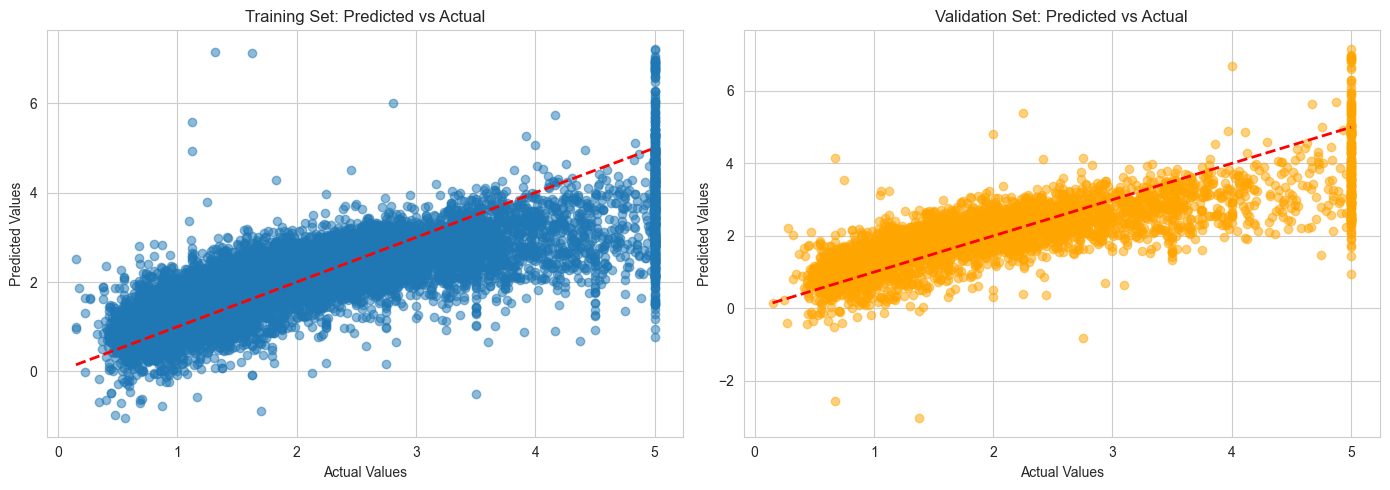

💡 Points close to the red line indicate good predictions
   Points far from the line show prediction errors


In [11]:
# Predicted vs Actual
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Training set
axes[0].scatter(y_train, y_pred_linear_train, alpha=0.5)
axes[0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual Values')
axes[0].set_ylabel('Predicted Values')
axes[0].set_title('Training Set: Predicted vs Actual')

# Validation set
axes[1].scatter(y_val, y_pred_linear_val, alpha=0.5, color='orange')
axes[1].plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--', lw=2)
axes[1].set_xlabel('Actual Values')
axes[1].set_ylabel('Predicted Values')
axes[1].set_title('Validation Set: Predicted vs Actual')

plt.tight_layout()
plt.show()

print("💡 Points close to the red line indicate good predictions")
print("   Points far from the line show prediction errors")

**Reading the output:**

The two scatter plots compare true `MedHouseVal` (x-axis) to predictions (y-axis) for training and validation. Points hugging the red 45-degree line indicate accurate predictions. At the right edge you will notice a **vertical** column of points at an actual value of \~5.0: the dataset records every median value above USD 500k at that ceiling, so all of those tracts share one actual value while the model's predictions for them spread up and down the column. The model itself is not capped — a linear model is unconstrained, and on the validation set it predicts 52 tracts above USD 500k and 24 below zero. Dispersion around the line is wider at higher actual values, consistent with the heteroskedasticity observed in the residual plots.

**Why this matters:** This plot is the fastest way to communicate model quality to HomeValue's CEO or a real estate agent. A tight cluster along the diagonal is immediately interpretable as "the model works." The vertical column at the ceiling also warns that the dataset has a truncation issue — tracts recorded at USD 500k could actually be worth USD 600k or USD 800k — so errors measured on those tracts are themselves uncertain. The pricing team should flag these capped tracts as "estimate unreliable" in client reports, and treat negative or above-ceiling predictions as a signal to sanity-check outputs before they reach a client.

---

## 8. Test Set Lockbox Discipline

HomeValue's pricing tool will be evaluated on properties it has never seen — clients won't bring properties from the training data. The test set simulates this reality: **4,128 census tracts** the model has never touched.

### The Test Set Rule:

> **"Touch the test set ONCE, at the very end"**

**Why this rule protects HomeValue's credibility:**
- Every peek at test performance tempts you to adjust the model — subtly fitting to the test data
- After multiple peeks, the "final" test score is optimistically biased: it no longer estimates real-world performance
- A client asking *"How accurate is your pricing tool?"* deserves an honest number, not one inflated by repeated test-set peeking

**What to do instead:**
- Use the validation set (4,128 tracts) for all model selection and tuning
- Use cross-validation for robust comparisons
- Only evaluate on test when you are completely done

**Warning signs you're peeking:**
- "Let me just check test performance real quick"
- "The test score is lower, let me adjust..."
- Running multiple experiments and checking test each time

In [12]:
print("=== TEST SET STATUS ===")
print(f"Test set size: {len(X_test)} samples")
print(f"Test set is LOCKED 🔒")
print(f"\n✓ We will NOT evaluate on test until the final submission")
print(f"✓ All model development uses only train + validation")

=== TEST SET STATUS ===
Test set size: 4128 samples
Test set is LOCKED 🔒

✓ We will NOT evaluate on test until the final submission
✓ All model development uses only train + validation


**Reading the output:**

The printout confirms that the test set contains **4,128 census tracts** and remains locked. No test-set metrics have been computed anywhere in this notebook — exactly as intended. This discipline is central to honest evaluation: the test set is HomeValue's one-time, final report card. If you evaluate on it repeatedly and adjust the model based on those numbers, you are effectively fitting to the test set, and the accuracy number you report to the board will be optimistically biased.

**Key takeaway:** Treat the test set like a sealed envelope. You will open it once, at the very end of the modeling process, and report whatever number comes out to the CEO — good or bad. This is how HomeValue maintains credibility with clients and stakeholders.

---

## 9. Evaluation Documentation Template

HomeValue's data science team needs a standard format for documenting every model evaluation — not just for this notebook, but for every model the company builds. This template ensures that anyone reviewing the work (the CEO, a new team member, an auditor) can understand *what* was measured, *how* it was measured, and *why* those choices were made.

### Evaluation Plan

**Primary Metric:** [MAE / RMSE / R²]  
**Rationale:** [Why this metric's loss matches HomeValue's intended use — e.g., "MAE because the cost of a miss grows roughly in proportion to its size"; report the other metrics as supporting scores for every model]

**Split Strategy:**
- Training: 60% (12,384 tracts for fitting)
- Validation: 20% (4,128 tracts for selection)
- Test: 20% (4,128 tracts for final evaluation)

**Baseline:** [Mean / Median predictor]  
**Baseline Performance:** [Validation MAE \~USD 91,400 (mean) / \~USD 88,700 (median)]

**Model:** [Linear Regression with Standard Scaling]  
**Model Performance:** [Validation MAE \~USD 52,600 · RMSE \~USD 71,800 · R² 0.617]  
**Improvement over Baseline:** [42.5% lower validation MAE than the mean baseline; 40.7% lower than the median baseline]

**Assumptions:**
- Features (`MedInc`, `HouseAge`, etc.) are available at prediction time
- Relationship between features and `MedHouseVal` is approximately linear
- No major data quality issues beyond the USD 500k cap

**Risks:**
- Model may not generalize to different time periods or housing markets
- The USD 500k cap truncates the target, biasing predictions for luxury properties
- Heteroskedasticity means one overall error figure understates uncertainty for expensive tracts
- The target is a 1990 census block-group median, not an individual sale price
- The linear model is unconstrained: it can predict negative or above-ceiling values

## 10. Wrap-Up: Key Takeaways

### What We Learned Today:

1. **Metrics Matter**: Choose MAE/RMSE/R² based on business loss function
2. **Baselines First**: Always establish a simple baseline for comparison
3. **Holdout Discipline**: Train on train, evaluate on validation, lock test away
4. **Residuals Tell Stories**: Use diagnostic plots to spot issues
5. **Document Everything**: Clear evaluation plans prevent confusion later

### Critical Rules:

> **"If your model can't beat the mean, debug before proceeding"**

> **"The test set is a lockbox - open it once"**

### Next Steps:

- Next notebook: Linear regression with features and diagnostics
- We'll build on today's evaluation framework
- Start thinking about which metrics matter for your project

---

## Participation Assignment Submission Instructions

### To Submit This Notebook:

1. **Complete all exercises**: Fill in both PAUSE-AND-DO exercise cells with your findings
2. **Run All Cells**: Execute `Runtime → Run all` to ensure everything works
3. **Save a Copy**: `File → Save a copy in Drive or Download the .ipynb extension`
4. **Submit**: Upload your `.ipynb` file in the participation assignment you find in the course Brightspace page.

### Before Submitting, Check:

- [ ] All cells execute without errors
- [ ] All outputs are visible
- [ ] Both exercise responses are complete
- [ ] Notebook is shared with correct permissions
- [ ] You can explain every line of code you wrote

### Next Step:

Complete the **Quiz** in Brightspace (auto-graded)

---

## 11. Submission Instructions

### To Submit:

1. Run all cells
2. Complete both exercises
3. Write a 3-sentence evaluation note answering:
   - Which metric is most appropriate for this problem and why?
   - How much better is linear regression than the baseline?
   - What does the residual analysis suggest?
4. Submit Colab link + evaluation note in LMS

---

## Bibliography

- James, G., Witten, D., Hastie, T., & Tibshirani, R. (2021). *An Introduction to Statistical Learning with Python* - Chapter on Model Assessment and Selection
- Hastie, T., Tibshirani, R., & Friedman, J. (2009). *The Elements of Statistical Learning* - Test error, training error, bias-variance
- scikit-learn User Guide: [Regression metrics](https://scikit-learn.org/stable/modules/model_evaluation.html#regression-metrics)
- scikit-learn User Guide: [Common pitfalls](https://scikit-learn.org/stable/common_pitfalls.html)

---



<center>

Thank you!

</center>